📌 1. Download the NIST SP 800-53 Rev. 5 Excel catalog

In [1]:
# 📥 Step 1: Download the Excel file from NIST
import requests

url = "https://csrc.nist.gov/files/pubs/sp/800/53/r5/upd1/final/docs/sp800-53r5-control-catalog.xlsx"
filename = "sp800-53r5-control-catalog.xlsx"

response = requests.get(url)

if response.status_code == 200:
    with open(filename, "wb") as f:
        f.write(response.content)
    print(f"✅ File successfully downloaded and saved as '{filename}'")
else:
    print(f"❌ Download failed. Status code: {response.status_code}")

✅ File successfully downloaded and saved as 'sp800-53r5-control-catalog.xlsx'


📌 2. Load the Excel catalog into a DataFrame

In [ ]:
# 📊 Step 2: Load the Excel file into a pandas DataFrame
import pandas as pd

xlsx = pd.ExcelFile(filename)
print("📄 Available sheets:", xlsx.sheet_names)

# Load the main control catalog sheet
df = xlsx.parse("SP 800-53 Revision 5")

# Display first few rows
df.head()

📄 Available sheets: ['SP 800-53 Revision 5']


,Control Identifier,Control (or Control Enhancement) Name,Control Text,Discussion,Related Controls
0,AC-1,Policy and Procedures,"a. Develop, document, and disseminate to [Assi...",Access control policy and procedures address t...,"IA-1, PM-9, PM-24, PS-8, SI-12 ."
1,AC-2,Account Management,a. Define and document the types of accounts a...,Examples of system account types include indiv...,"AC-3, AC-5, AC-6, AC-17, AC-18, AC-20, AC-24, ..."
2,AC-2(1),Account Management | Automated System Account ...,Support the management of system accounts usin...,Automated system account management includes u...,None.
3,AC-2(2),Account Management | Automated Temporary and E...,Automatically [Selection: remove; disable] tem...,Management of temporary and emergency accounts...,None.
4,AC-2(3),Account Management | Disable Accounts,Disable accounts within [Assignment: organizat...,"Disabling expired, inactive, or otherwise anom...",None.


📌 3. Keep only relevant columns

In [ ]:
# 📎 Step 3: Keep only useful columns for analysis
df = df[['Control Identifier', 'Control (or Control Enhancement) Name', 'Control Text']]
df.dropna(subset=['Control Text'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Rename columns for simplicity
df.columns = ['Control ID', 'Control Name', 'Control Text']
df.head()

/tmp/ipython-input-3-709492158.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['Control Text'], inplace=True)


,Control ID,Control Name,Control Text
0,AC-1,Policy and Procedures,"a. Develop, document, and disseminate to [Assi..."
1,AC-2,Account Management,a. Define and document the types of accounts a...
2,AC-2(1),Account Management | Automated System Account ...,Support the management of system accounts usin...
3,AC-2(2),Account Management | Automated Temporary and E...,Automatically [Selection: remove; disable] tem...
4,AC-2(3),Account Management | Disable Accounts,Disable accounts within [Assignment: organizat...


📌 4. Install and load spaCy

In [ ]:
# 🧠 Step 3: Install and load the English NLP model with spaCy
import spacy

# Load the small English model
nlp = spacy.load("en_core_web_sm")
print("✅ spaCy model loaded successfully.")

✅ spaCy model loaded successfully.


📌 5. Inspect one control with spaCy

In [ ]:
# 🔍 Step 5: Apply spaCy to a sample control for inspection
sample_text = df['Control Text'].iloc[6]
doc = nlp(sample_text)

print("📝 Original control:\n", sample_text)
print("\n📌 Noun chunks:")
for chunk in doc.noun_chunks:
    print("-", chunk.text)

print("\n📌 Verbs:")
for token in doc:
    if token.pos_ == "VERB":
        print("-", token.lemma_)

📝 Original control:
 Require that users log out when [Assignment: organization-defined time period of expected inactivity or description of when to log out].

📌 Noun chunks:
- users
- organization-defined time period
- expected inactivity
- description

📌 Verbs:
- require
- log
- define
- expect
- log


📌 6. Clean and normalize the control text

In [ ]:
# 🧹 Step 6: Clean and normalize control text for NLP processing

import re

def clean_control_text(text):
    # 1. Preserve Assignment content
    text = re.sub(
        r"\[Assignment:\s*([^\]]+)\]",
        r"\1",
        text
    )
    # 2. Preserve Selection content, join options with "or"
    def sel_repl(m):
        options = [opt.strip() for opt in m.group(1).split(';')]
        return " or ".join(options)
    text = re.sub(
        r"\[Selection:\s*([^\]]+)\]",
        sel_repl,
        text
    )
    # 3. Remove any other bracketed placeholders
    text = re.sub(r"\[.*?\]", "", text)
    # 4. Remove leading bullets or clause markers
    text = re.sub(r"^\s*(?:[a-z]\.|\d+\.|\(\w+\))\s*", "", text)
    # 5. Remove subclause markers like "(a)", "(1)", etc.
    text = re.sub(r"\(\w+\)", "", text)
    # 6. Clean stray punctuation and normalize spacing
    text = re.sub(r"\s*[:\.]\s*", " ", text)
    text = re.sub(r"\.{2,}", ".", text)
    text = text.strip()
    if not text.endswith("."):
        text += "."
    text = re.sub(r"\s+", " ", text)
    return text

# Apply cleaning function
df['Cleaned Text'] = df['Control Text'].apply(clean_control_text)

# Show cleaned version for first few controls
df[['Control ID', 'Control Text', 'Cleaned Text']].head()

,Control ID,Control Text,Cleaned Text
0,AC-1,"a. Develop, document, and disseminate to [Assi...","Develop, document, and disseminate to organiza..."
1,AC-2,a. Define and document the types of accounts a...,Define and document the types of accounts allo...
2,AC-2(1),Support the management of system accounts usin...,Support the management of system accounts usin...
3,AC-2(2),Automatically [Selection: remove; disable] tem...,Automatically remove or disable temporary and ...
4,AC-2(3),Disable accounts within [Assignment: organizat...,Disable accounts within organization-defined t...


📌 7. Export the cleaned NIST controls to CSV

In [ ]:
# 💾 Step 7: Export the cleaned DataFrame to CSV
output_filename = "nist_controls_cleaned.csv"
df.to_csv(output_filename, index=False)
print(f"✅ File saved as '{output_filename}'")

# 📥 Enable download from Colab
from google.colab import files
files.download(output_filename)

✅ File saved as 'nist_controls_cleaned.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📌 8. Install and load the spaCy transformer model

In [ ]:
# 🧠 Step 8: Install and load the spaCy transformer model
!pip install -U spacy
!python -m spacy download en_core_web_md

import spacy
nlp = spacy.load("en_core_web_md")
print("✅ Loaded spaCy medium model: en_core_web_md")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 54.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Loaded spaCy medium model: en_core_web_md


📌 9. Define function to extract SVO and noun chunks

In [ ]:
# 🔍 Step 9: Define function to extract Subjects, Verbs, Objects, and Noun Chunks
def extract_svo_and_noun_chunks(text):
    """
    Processes text and returns:
      - Subjects (nsubj)
      - Verbs (lemma of VERB tokens)
      - Objects (dobj, pobj)
      - Noun chunks
    """
    doc = nlp(text)
    subjects    = [tok.text for tok in doc if tok.dep_ == "nsubj"]
    verbs       = [tok.lemma_ for tok in doc if tok.pos_ == "VERB"]
    objects     = [tok.text for tok in doc if tok.dep_ in ("dobj", "pobj")]
    noun_chunks = [chunk.text for chunk in doc.noun_chunks]
    return {
        "Subjects": subjects,
        "Verbs": verbs,
        "Objects": objects,
        "Noun Chunks": noun_chunks
    }

📌 10. Apply SVO extraction to all controls

In [ ]:
# 🔁 Step 10: Apply SVO extraction to all controls

import pandas as pd

# 1. Applica la funzione a tutta la colonna 'Cleaned Text'
svo_df = df['Cleaned Text'] \
    .apply(extract_svo_and_noun_chunks) \
    .apply(pd.Series)

# 2. Unisci le nuove colonne al DataFrame originale
df_svo = pd.concat([df, svo_df], axis=1)

# 3. (Opzionale) Controlla le prime righe
df_svo.head()

,Control ID,Control Name,Control Text,Cleaned Text,Subjects,Verbs,Objects,Noun Chunks
0,AC-1,Policy and Procedures,"a. Develop, document, and disseminate to [Assi...","Develop, document, and disseminate to organiza...",[Addresses],"[develop, disseminate, define, purpose, facili...","[personnel, that, entities, laws, implementati...","[document, organization-defined personnel, rol..."
1,AC-2,Account Management,a. Define and document the types of accounts a...,Define and document the types of accounts allo...,"[i, Review, k]","[define, document, allow, prohibit, define, au...","[types, accounts, use, system, membership, sys...","[the types, accounts, use, the system, group a..."
2,AC-2(1),Account Management | Automated System Account ...,Support the management of system accounts usin...,Support the management of system accounts usin...,[],"[support, use, define, automate]","[management, accounts, mechanisms]","[the management, system accounts, organization..."
3,AC-2(2),Account Management | Automated Temporary and E...,Automatically [Selection: remove; disable] tem...,Automatically remove or disable temporary and ...,[],"[remove, disable, define]","[accounts, period, type, account]","[temporary and emergency accounts, organizatio..."
4,AC-2(3),Account Management | Disable Accounts,Disable accounts within [Assignment: organizat...,Disable accounts within organization-defined t...,[accounts],"[define, expire, associate, define]","[accounts, period, user, violation, policy, pe...","[accounts, organization-defined time period, t..."


📌 11. Save the full SVO-enriched DataFrame to CSV and download

In [ ]:
# 💾 Step 11: Save the full SVO-enriched DataFrame to CSV and download

output_filename = "nist_controls_svo.csv"
df_svo.to_csv(output_filename, index=False)
print(f"✅ Saved SVO-enriched controls as '{output_filename}'")

from google.colab import files
files.download(output_filename)

✅ Saved SVO-enriched controls as 'nist_controls_svo.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import random

# Carica il CSV
df_svo = pd.read_csv("nist_controls_svo.csv")

# Estrai 10 righe casuali
sample = df_svo.sample(10, random_state=42)

# Stampa in modo leggibile
for _, row in sample.iterrows():
    print(f"--- Control {row['Control ID']} ---")
    print("Cleaned Text:", row['Cleaned Text'])
    print("  Subjects:", row['Subjects'])
    print("  Verbs   :", row['Verbs'])
    print("  Objects :", row['Objects'])
    print("  Noun Chks:", row['Noun Chunks'])
    print()

--- Control CM-9 ---
Cleaned Text: Develop, document, and implement a configuration management plan for the system that a Addresses roles, responsibilities, and configuration management processes and procedures; b Establishes a process for identifying configuration items throughout the system development life cycle and for managing the configuration of the configuration items; c Defines the configuration items for the system and places the configuration items under configuration management; d Is reviewed and approved by organization-defined personnel or roles; and e Protects the configuration management plan from unauthorized disclosure and modification.
  Subjects: ['roles', 'b', 'c', 'e']
  Verbs   : ['develop', 'implement', 'establish', 'identify', 'manage', 'define', 'place', 'review', 'approve', 'define', 'protect']
  Objects : ['plan', 'system', 'process', 'items', 'cycle', 'configuration', 'items', 'items', 'system', 'items', 'management', 'personnel', 'plan', 'disclosure']
  No

In [ ]:
import pandas as pd

df_svo = pd.read_csv("nist_controls_svo.csv")

total = len(df_svo)
no_subj = df_svo['Subjects'].apply(lambda x: x == "[]").sum()
no_obj  = df_svo['Objects'].apply(lambda x: x == "[]").sum()

print(f"Total controls       : {total}")
print(f"Without subject      : {no_subj} ({no_subj/total:.1%})")
print(f"Without object       : {no_obj} ({no_obj/total:.1%})")

Total controls       : 1189
Without subject      : 857 (72.1%)
Without object       : 188 (15.8%)


📌 11. Improve SVO Extraction

In [ ]:
# 🔍 Advanced SVO extraction with default subject for imperatives
def extract_svo_and_noun_chunks_v2(text):
    doc = nlp(text)
    # Subjects (active & passive); default to "organization" if imperative
    subjects = [tok.text for tok in doc if tok.dep_ in ("nsubj","nsubjpass")]
    if not subjects and doc and doc[0].pos_ == "VERB":
        subjects = ["organization"]

    # Verbs (lemmas)
    verbs = [tok.lemma_ for tok in doc if tok.pos_ == "VERB"]

    # Objects (direct, prepositional, dative, attribute)
    objects = [tok.text for tok in doc
               if tok.dep_ in ("dobj","pobj","dative","attr")]

    # Noun chunks
    noun_chunks = [chunk.text for chunk in doc.noun_chunks]

    return {
        "Subjects": subjects,
        "Verbs": verbs,
        "Objects": objects,
        "Noun Chunks": noun_chunks
    }

In [ ]:
import pandas as pd

# Optional: filtra via controlli troppo corti
valid_df = df[df['Cleaned Text'].str.len() > 5].copy()

# Step 10: estrai SVO su valid_df
svo_df = valid_df['Cleaned Text'] \
    .apply(extract_svo_and_noun_chunks_v2) \
    .apply(pd.Series)

# Unisci al DataFrame originale
df_svo_v2 = pd.concat([valid_df, svo_df], axis=1)

# Verifica le prime righe
df_svo_v2.head()

,Control ID,Control Name,Control Text,Cleaned Text,Subjects,Verbs,Objects,Noun Chunks
0,AC-1,Policy and Procedures,"a. Develop, document, and disseminate to [Assi...","Develop, document, and disseminate to organiza...",[Addresses],"[develop, disseminate, define, purpose, facili...","[personnel, that, entities, laws, implementati...","[document, organization-defined personnel, rol..."
1,AC-2,Account Management,a. Define and document the types of accounts a...,Define and document the types of accounts allo...,"[accounts, users, i, Review, k, individuals]","[define, document, allow, prohibit, define, au...","[types, accounts, use, system, membership, sys...","[the types, accounts, use, the system, group a..."
2,AC-2(1),Account Management | Automated System Account ...,Support the management of system accounts usin...,Support the management of system accounts usin...,[organization],"[support, use, define, automate]","[management, accounts, mechanisms]","[the management, system accounts, organization..."
3,AC-2(2),Account Management | Automated Temporary and E...,Automatically [Selection: remove; disable] tem...,Automatically remove or disable temporary and ...,[],"[remove, disable, define]","[accounts, period, type, account]","[temporary and emergency accounts, organizatio..."
4,AC-2(3),Account Management | Disable Accounts,Disable accounts within [Assignment: organizat...,Disable accounts within organization-defined t...,[accounts],"[define, expire, associate, define]","[accounts, period, user, violation, policy, pe...","[accounts, organization-defined time period, t..."


In [ ]:
# Step 11: salva e scarica
output_filename = "nist_controls_svo_v2.csv"
df_svo_v2.to_csv(output_filename, index=False)
print(f"✅ Saved SVO v2 as '{output_filename}'")

from google.colab import files
files.download(output_filename)

✅ Saved SVO v2 as 'nist_controls_svo_v2.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📌 12. Compute SVO Extraction Metrics to check result

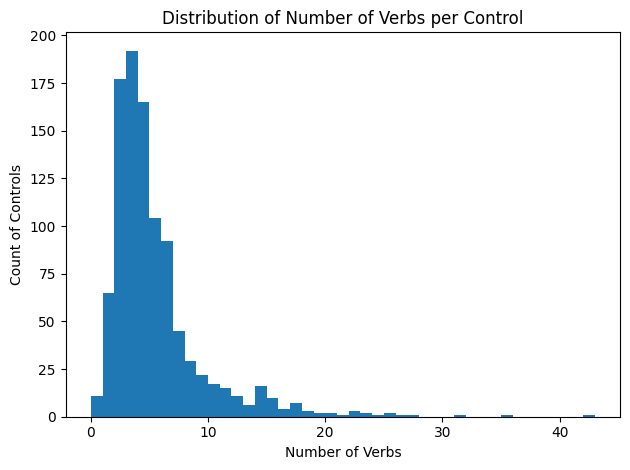

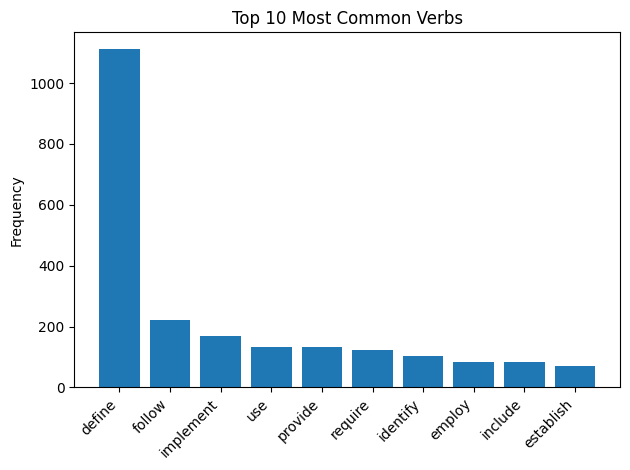

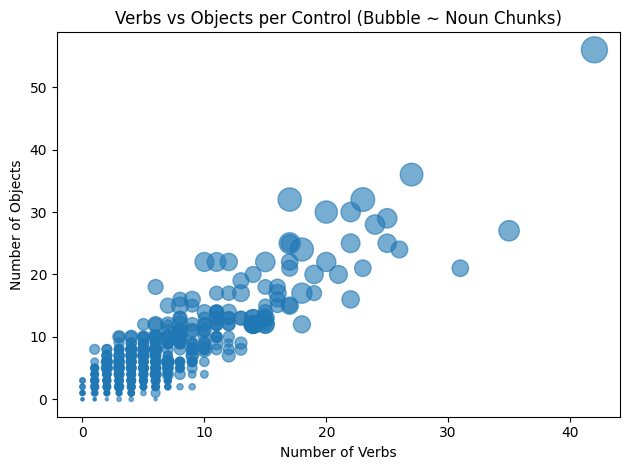

In [ ]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt

# Load SVO-enriched data
df = pd.read_csv('nist_controls_svo_v2.csv')

# Parse list columns
for col in ['Subjects', 'Verbs', 'Objects', 'Noun Chunks']:
    df[col] = df[col].apply(ast.literal_eval)

# Compute count columns
df['num_subjects'] = df['Subjects'].apply(len)
df['num_verbs']    = df['Verbs'].apply(len)
df['num_objects']  = df['Objects'].apply(len)
df['num_chunks']   = df['Noun Chunks'].apply(len)

# Top 10 verbs
all_verbs = [v for verbs in df['Verbs'] for v in verbs]
verb_counts = Counter(all_verbs)
top_verbs = verb_counts.most_common(10)
verbs, freqs = zip(*top_verbs)

# 1) Histogram of verbs per control
plt.figure()
plt.hist(df['num_verbs'], bins=range(0, max(df['num_verbs'])+2))
plt.title('Distribution of Number of Verbs per Control')
plt.xlabel('Number of Verbs')
plt.ylabel('Count of Controls')
plt.tight_layout()
plt.show()

# 2) Bar chart of Top 10 Verbs
plt.figure()
plt.bar(verbs, freqs)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Most Common Verbs')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 3) Bubble chart: verbs vs objects
plt.figure()
sizes = df['num_chunks'] * 5
plt.scatter(df['num_verbs'], df['num_objects'], s=sizes, alpha=0.6)
plt.title('Verbs vs Objects per Control (Bubble ∼ Noun Chunks)')
plt.xlabel('Number of Verbs')
plt.ylabel('Number of Objects')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import ast

# 🔄 Load the SVO-enriched CSV
df = pd.read_csv("nist_controls_svo_v2.csv")

# 🔄 Parse the stringified lists back into Python lists
for col in ['Subjects', 'Verbs', 'Objects', 'Noun Chunks']:
    df[col] = df[col].apply(ast.literal_eval)

# ➕ Compute counts per control
df['num_subjects'] = df['Subjects'].apply(len)
df['num_verbs']    = df['Verbs'].apply(len)
df['num_objects']  = df['Objects'].apply(len)
df['num_chunks']   = df['Noun Chunks'].apply(len)

# 📊 Compute overall metrics
total_controls      = len(df)
pct_subjects        = (df['num_subjects'] > 0).mean() * 100
pct_objects         = (df['num_objects'] > 0).mean() * 100
avg_subjects        = df['num_subjects'].mean()
avg_verbs           = df['num_verbs'].mean()
avg_objects         = df['num_objects'].mean()
avg_chunks          = df['num_chunks'].mean()

# 📋 Build a DataFrame for presentation
metrics = {
    'Metric': [
        'Total valid controls',
        'Controls with ≥ 1 subject',
        'Controls with ≥ 1 object',
        'Average subjects per control',
        'Average verbs per control',
        'Average objects per control',
        'Average noun-chunks per control'
    ],
    'Value': [
        f"{total_controls:,}",
        f"{pct_subjects:.1f}%",
        f"{pct_objects:.1f}%",
        f"{avg_subjects:.2f}",
        f"{avg_verbs:.2f}",
        f"{avg_objects:.2f}",
        f"{avg_chunks:.2f}"
    ]
}

metrics_df = pd.DataFrame(metrics)

# 🔍 Display in Colab
metrics_df

,Metric,Value
0,Total valid controls,"1,009"
1,Controls with ≥ 1 subject,88.1%
2,Controls with ≥ 1 object,99.2%
3,Average subjects per control,1.25
4,Average verbs per control,5.03
5,Average objects per control,5.47
6,Average noun-chunks per control,8.12


📌 13. Semantic thematic classification

In [ ]:
import pandas as pd

# 🔄 Load the SVO-enriched dataset
df = pd.read_csv("nist_controls_svo_v2.csv")

# 🔧 Define mapping prefix → Control Family
family_map = {
    'AC': 'Access Control',
    'AT': 'Awareness and Training',
    'AU': 'Audit and Accountability',
    'CA': 'Assessment, Authorization and Monitoring',
    'CM': 'Configuration Management',
    'CP': 'Contingency Planning',
    'IA': 'Identification and Authentication',
    'IR': 'Incident Response',
    'MA': 'Maintenance',
    'MP': 'Media Protection',
    'PE': 'Physical and Environmental Protection',
    'PL': 'Planning',
    'PM': 'Program Management',
    'PS': 'Personnel Security',
    'PT': 'PII Processing and Transparency',
    'RA': 'Risk Assessment',
    'SA': 'System and Services Acquisition',
    'SC': 'System and Communications Protection',
    'SI': 'System and Information Integrity',
    'SR': 'Supply Chain Risk Management'
}

# 📋 Extract the family code (prefix) and map to full name
df['Control Family Code'] = df['Control ID'].str.extract(r'^([A-Z]+)')
df['Control Family'] = df['Control Family Code'].map(family_map).fillna('Other')

# 📄 Preview the new columns
df[['Control ID','Control Family Code','Control Family']].drop_duplicates().head(10)

# 💾 Save updated dataset
output_filename = "nist_controls_svo_v2_with_family.csv"
df.to_csv(output_filename, index=False)
print(f"✅ Saved augmented dataset as '{output_filename}'")

from google.colab import files
files.download(output_filename)

✅ Saved augmented dataset as 'nist_controls_svo_v2_with_family.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📌 14. Plot number of controls for each categories

In [ ]:
import pandas as pd

# 🔄 Load the augmented dataset with Control Family
df = pd.read_csv("nist_controls_svo_v2_with_family.csv")

# 📊 Count controls per Control Family
family_counts = df['Control Family'].value_counts().reset_index()
family_counts.columns = ['Control Family', 'Control Count']

# (Opzionale) Add percentage column
total = len(df)
family_counts['Percentage'] = (family_counts['Control Count'] / total * 100).round(1).astype(str) + '%'

# 🔍 Display the result
family_counts

,Control Family,Control Count,Percentage
0,System and Communications Protection,139,13.8%
1,Access Control,131,13.0%
2,System and Services Acquisition,106,10.5%
3,System and Information Integrity,101,10.0%
4,Identification and Authentication,56,5.6%
5,Configuration Management,56,5.6%
6,Audit and Accountability,56,5.6%
7,Physical and Environmental Protection,51,5.1%
8,Contingency Planning,50,5.0%
9,Incident Response,40,4.0%
